In [83]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely import wkt
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

In [84]:
# Load CSV with demand data
path = "C://Users//Carlos//OneDrive - Universite de Liege//Documents//2025//Articulos y publicaciones//IAEEE - 2025//final_results_3.xls"
df = pd.read_excel(path)

#dropping corrupted columns
df = df.drop(columns=['geometry'], axis=1)

df.head()

,ogc_fid,id,objectid,c_ut,departamen,provincia,municipio,capital,shape_leng,shape_area,...,Total consumption (MWh),Unnamed: 43,Unnamed: 44,Unnamed: 45,Unnamed: 46,Unnamed: 47,Unnamed: 48,Unnamed: 49,Unnamed: 50,Unnamed: 51
0,2,48,764,40202,Oruro,Abaroa,Santuario de Quillacas,Santuario de Quillacas,168822.092913,9.275470e+08,...,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,67,308,1055,40601,Oruro,PoopÃ³,PoopÃ³,Villa de PoopÃ³,147945.813239,6.856796e+08,...,59.4880,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,111,44,760,41503,Oruro,Mejillones,Carangas,Carangas,85089.931692,2.263553e+08,...,13.2775,NaN,Total consumption (sub sufficiency) - GWh/year,NaN,NaN,NaN,Population under sufficiency,NaN,NaN,Average consumption per capita (under sufficie...
3,117,58,769,41202,Oruro,Sur Carangas,BelÃ©n de Andamarca,BelÃ©n de Andamarca,174432.410434,1.063036e+09,...,37.4500,NaN,843.863996,NaN,NaN,NaN,5933895,NaN,NaN,142.210807
4,316,309,1056,40502,Oruro,Litoral,Escara,Escara,184178.493888,1.327037e+09,...,54.5220,NaN,Total consumption (over sufficiency) - GWh/year,NaN,NaN,NaN,Population over sufficiency,NaN,NaN,Average consumption per capita (over sufficien...


In [85]:
#renaming datasets
df.rename(columns={"mean":"demand (MWh/HH)"}, inplace=True)
df['relation to sufficiency'] = df["demand (MWh/HH)"]/df["sufficiency"]

In [86]:
# Load shp file with geometries data
path2 = r"C:\Users\Carlos\OneDrive - Universite de Liege\Documents\2025\Articulos y publicaciones\IAEEE - 2025\Sources\Archetypes\Municipalities data\Map_municipalities\municipios339.shp"
gdf = gpd.read_file(path2)
gdf.head()

,ogc_fid,id,objectid,c_ut,departamen,provincia,municipio,capital,shape_leng,shape_area,geometry
0,1,47.0,763.0,040505,Oruro,Litoral,Esmeralda,Esmeralda,157773.865159,5.826799e+08,"POLYGON ((-68.26703 -18.81616, -68.26279 -18.8..."
1,2,48.0,764.0,040202,Oruro,Abaroa,Santuario de Quillacas,Santuario de Quillacas,168822.092913,9.275470e+08,"POLYGON ((-66.50208 -19.35990, -66.54577 -19.3..."
2,3,49.0,765.0,040802,Oruro,Ladislao Cabrera,Pampa Aullagas,Pampa Aullagas,170278.352785,1.011607e+09,"POLYGON ((-67.05305 -19.09035, -67.05290 -19.0..."
3,4,55.0,772.0,050203,PotosÃ­,Rafael Bustillo,Llallagua,Llallagua,108042.750490,5.243827e+08,"POLYGON ((-66.42997 -18.25647, -66.42895 -18.2..."
4,5,56.0,773.0,050702,PotosÃ­,Alonso de IbÃ¡Ã±ez,Caripuyo,Caripuyo,127710.107729,5.181230e+08,"POLYGON ((-66.55964 -18.07798, -66.55916 -18.0..."


In [87]:
# Merge DataFrame with Shapefile
gdf['c_ut'] = pd.to_numeric(gdf['c_ut'], errors='coerce')
df['c_ut'] = pd.to_numeric(df['c_ut'], errors='coerce')

merged_gdf = gdf.merge(
    df[['c_ut', 'demand (MWh/HH)', 'Consumo per capita (MWh/person)','Population_2024','sufficiency','Total consumption (MWh)','relation to sufficiency']],
    left_on='c_ut',
    right_on='c_ut',
    how='left'
)
# Verifica si los valores de 'Cluster' se asignaron correctamente
merged_gdf.head()

,ogc_fid,id,objectid,c_ut,departamen,provincia,municipio,capital,shape_leng,shape_area,geometry,demand (MWh/HH),Consumo per capita (MWh/person),Population_2024,sufficiency,Total consumption (MWh),relation to sufficiency
0,1,47.0,763.0,40505.0,Oruro,Litoral,Esmeralda,Esmeralda,157773.865159,5.826799e+08,"POLYGON ((-68.26703 -18.81616, -68.26279 -18.8...",0.069,0.01725,3883.0,1.355,66.98175,0.050923
1,2,48.0,764.0,40202.0,Oruro,Abaroa,Santuario de Quillacas,Santuario de Quillacas,168822.092913,9.275470e+08,"POLYGON ((-66.50208 -19.35990, -66.54577 -19.3...",0.000,0.00000,5105.0,1.355,0.00000,0.000000
2,3,49.0,765.0,40802.0,Oruro,Ladislao Cabrera,Pampa Aullagas,Pampa Aullagas,170278.352785,1.011607e+09,"POLYGON ((-67.05305 -19.09035, -67.05290 -19.0...",0.179,0.04475,3180.0,1.355,142.30500,0.132103
3,4,55.0,772.0,50203.0,PotosÃ­,Rafael Bustillo,Llallagua,Llallagua,108042.750490,5.243827e+08,"POLYGON ((-66.42997 -18.25647, -66.42895 -18.2...",0.650,0.16250,41571.0,1.355,6755.28750,0.479705
4,5,56.0,773.0,50702.0,PotosÃ­,Alonso de IbÃ¡Ã±ez,Caripuyo,Caripuyo,127710.107729,5.181230e+08,"POLYGON ((-66.55964 -18.07798, -66.55916 -18.0...",0.251,0.06275,8427.0,1.355,528.79425,0.185240


In [88]:
# Load departments map 
path3 = r"C:\Users\Carlos\OneDrive - Universite de Liege\Documents\2025\Articulos y publicaciones\IAEEE - 2025\Sources\Archetypes\Municipalities data\Map_departments\Tasa_Mortalidad_Ninez2015.shp"
departments_gdf = gpd.read_file(path3)

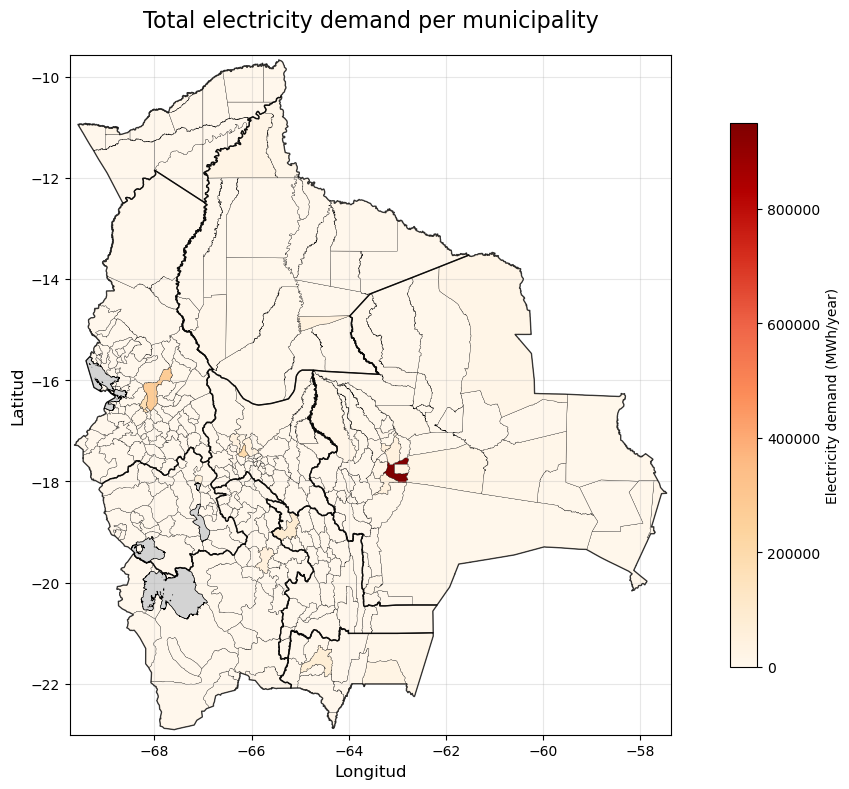

In [89]:
# Set figure size and plot
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
cmap = 'OrRd'

merged_gdf.plot(column='Total consumption (MWh)',
                cmap=cmap,
                linewidth=0.2,
                edgecolor='black',
                ax=ax,
                legend=True,
                legend_kwds={'label': 'Electricity demand (MWh/year)',
                           'orientation': 'vertical',
                           'shrink': 0.8})

no_data = merged_gdf[merged_gdf['Total consumption (MWh)'].isna()]
if len(no_data) > 0:
    no_data.plot(ax=ax, color='lightgray', edgecolor='black', linewidth=0.5)

departments_gdf.boundary.plot(ax=ax, color='black', linewidth=1, alpha=0.7)

ax.set_xlabel('Longitud', fontsize=12)
ax.set_ylabel('Latitud', fontsize=12)
ax.set_title('Total electricity demand per municipality', fontsize=16, pad=20)

ax.grid(True, alpha=0.3)

ax.set_xlim(merged_gdf.total_bounds[0] - 0.1, merged_gdf.total_bounds[2] + 0.1)
ax.set_ylim(merged_gdf.total_bounds[1] - 0.1, merged_gdf.total_bounds[3] + 0.1)

plt.tight_layout()
plt.show()

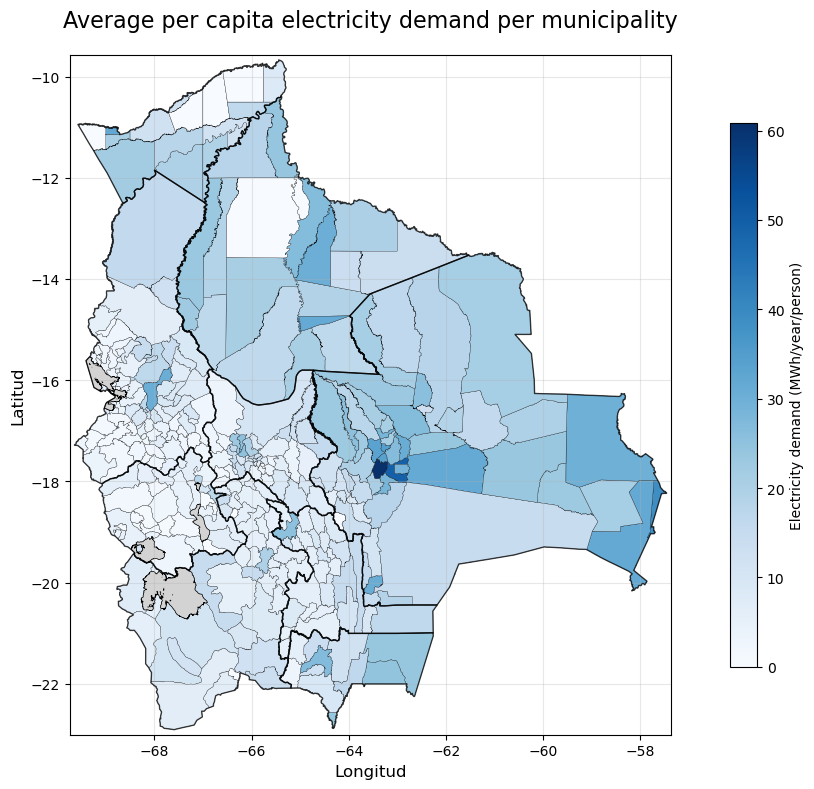

In [ ]:
# Set figure size and plot
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
cmap = 'Blues'

merged_gdf.plot(column=merged_gdf['Consumo per capita (MWh/person)'] * 1000 / 12,
                cmap=cmap,
                linewidth=0.2,
                edgecolor='black',
                ax=ax,
                legend=True,
                legend_kwds={'label': 'Electricity demand (kWh/month/person)',
                           'orientation': 'vertical',
                           'shrink': 0.8})

no_data = merged_gdf[merged_gdf['Consumo per capita (MWh/person)'].isna()]
if len(no_data) > 0:
    no_data.plot(ax=ax, color='lightgray', edgecolor='black', linewidth=0.5)

departments_gdf.boundary.plot(ax=ax, color='black', linewidth=1, alpha=0.7)

ax.set_xlabel('Longitud', fontsize=12)
ax.set_ylabel('Latitud', fontsize=12)
ax.set_title('Average per capita electricity demand per municipality', fontsize=16, pad=20)

ax.grid(True, alpha=0.3)

ax.set_xlim(merged_gdf.total_bounds[0] - 0.1, merged_gdf.total_bounds[2] + 0.1)
ax.set_ylim(merged_gdf.total_bounds[1] - 0.1, merged_gdf.total_bounds[3] + 0.1)

plt.tight_layout()
plt.show()

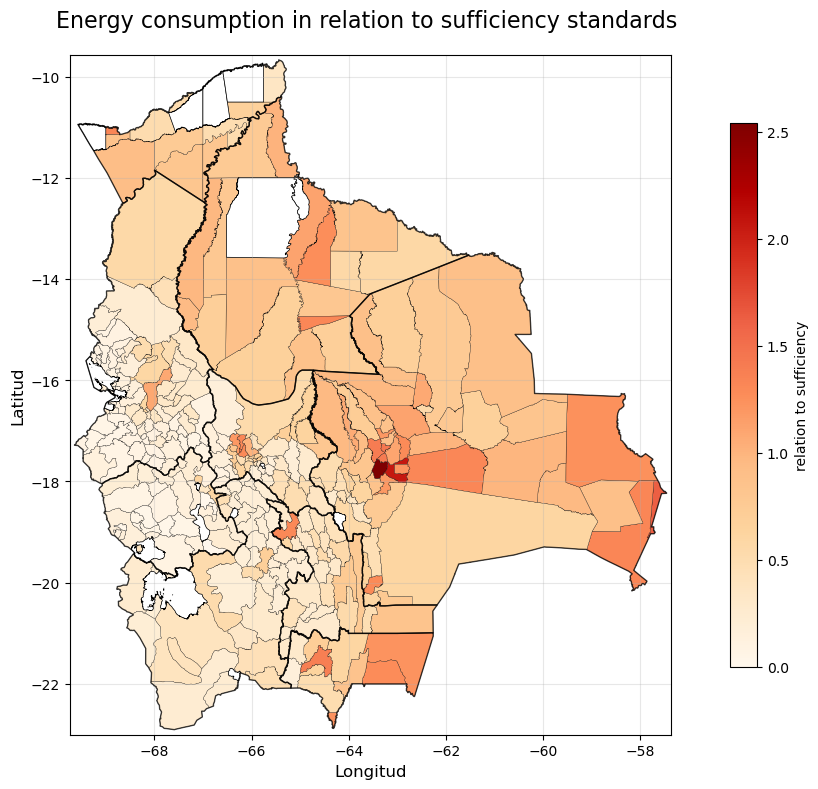

In [94]:
# Set figure size and plot
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
cmap = 'OrRd'

merged_gdf.plot(column='relation to sufficiency',
                cmap=cmap,
                linewidth=0.2,
                edgecolor='black',
                ax=ax,
                legend=True,
                legend_kwds={'label': 'relation to sufficiency',
                           'orientation': 'vertical',
                           'shrink': 0.8})

no_data = merged_gdf[merged_gdf['relation to sufficiency'].isna()]
if len(no_data) > 0:
    no_data.plot(ax=ax, color='white', edgecolor='black', linewidth=0.5)

departments_gdf.boundary.plot(ax=ax, color='black', linewidth=1, alpha=0.7)

ax.set_xlabel('Longitud', fontsize=12)
ax.set_ylabel('Latitud', fontsize=12)
ax.set_title('Energy consumption in relation to sufficiency standards ', fontsize=16, pad=20)

ax.grid(True, alpha=0.3)

ax.set_xlim(merged_gdf.total_bounds[0] - 0.1, merged_gdf.total_bounds[2] + 0.1)
ax.set_ylim(merged_gdf.total_bounds[1] - 0.1, merged_gdf.total_bounds[3] + 0.1)

plt.tight_layout()
plt.show()